In [4]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
from pathlib import Path
import shutil
import glob
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import weighted_value_per_det_type as wval_dtype
from resolution_extraction import weighted_resolution_per_detector_type as wres_dtype
from resolution_extraction import get_eres_per_detector
import resolution_extraction as rex

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"
# metadata2_path = os.environ["METADATA"]
metadata2_path = "/global/homes/b/borrfran/workspace/l200/legend-metadata"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']


meta = LegendMetadata(config['metadata'])
meta2 = LegendMetadata(metadata2_path)

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)

DET_TYPES = ("BEGe", "COAX", "ICPC", "PPC")
DET_TYPE_MAP = {"B": "BEGe", "C": "COAX", "V": "ICPC", "P": "PPC"}

simulated_energies = list(range(200, 1100, 100))

could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd5d76e5c10>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd5d76e4e50>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd5d76e5800>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd5d76e5a80>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7fd5d7506fc0>, 'did not find expected key', <yaml._yaml.Mark object at 0x7fd5d7504f40>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/l200/legend-metadata/jldat

In [6]:
full_df = pd.DataFrame()
for ene in tqdm(simulated_energies):

    tag = f"{ene}keV"
    job_string = f"fromfile_dark_compton_{tag}_hpge_bulk"
    
    cvt_file = glob.glob(f"{scratch_folder}/generated/tier/cvt/l200cfg01-{job_string}-tier_cvt.lh5")[0]
    
    # how_many[ene] = {}
    
    data = lh5.read_as(f"evt", cvt_file, field_mask=["coincident", "geds", "trigger"], library = 'ak')
    
    tmp  = data.geds[data.geds.multiplicity == 1]
    tmp2 = data.trigger[data.geds.multiplicity == 1]
    df = ak_to_pandas(tmp, tmp2)
    df['sim_e'] = np.full(len(df), ene, dtype=int)
    
    full_df = pd.concat([full_df, df], ignore_index=True)
pl_df = pl.from_pandas(full_df, include_index=False)
del full_df

  0%|          | 0/8 [00:00<?, ?it/s]

In [6]:
build_parquet_dataset(
    simulated_energies[3:],
    scratch_folder=scratch_folder,
    job_base="fromfile_dark_compton_{tag}_hpge_bulk",
    outdir_name="dark-compton",
    overwrite=True,
)

  0%|          | 0/6 [00:00<?, ?it/s]

In [14]:
rawid_by_det_type = Props.read_from('./v1/dictionaries/rawid_by_det_type.yaml')

In [8]:
outdir_name = "dark-compton"

In [11]:
lf = pl.scan_parquet(
    f"./v1/parquet/{outdir_name}",
    hive_partitioning=True
)

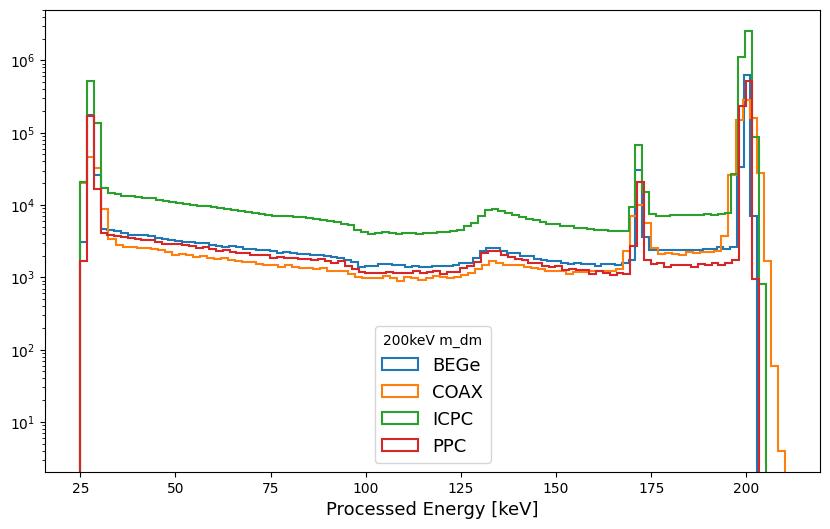

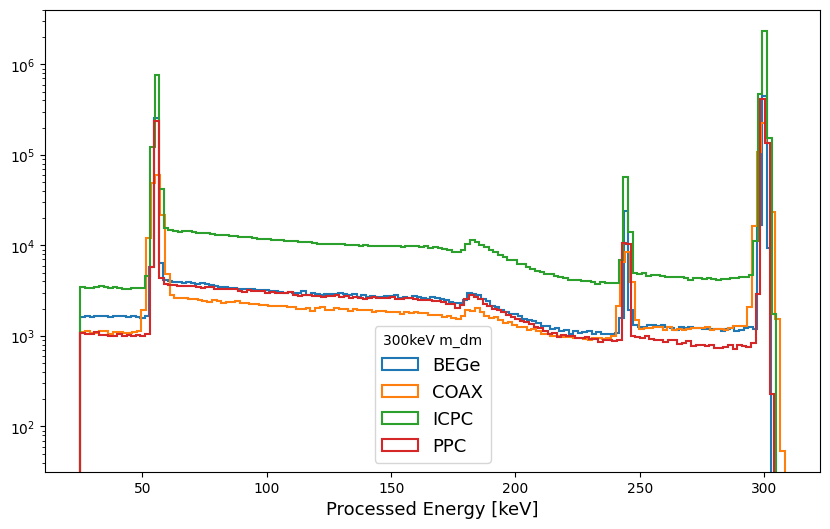

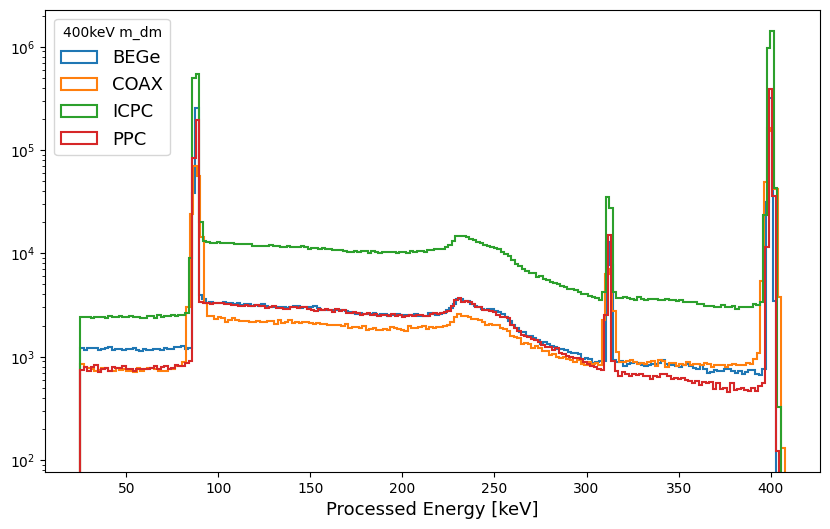

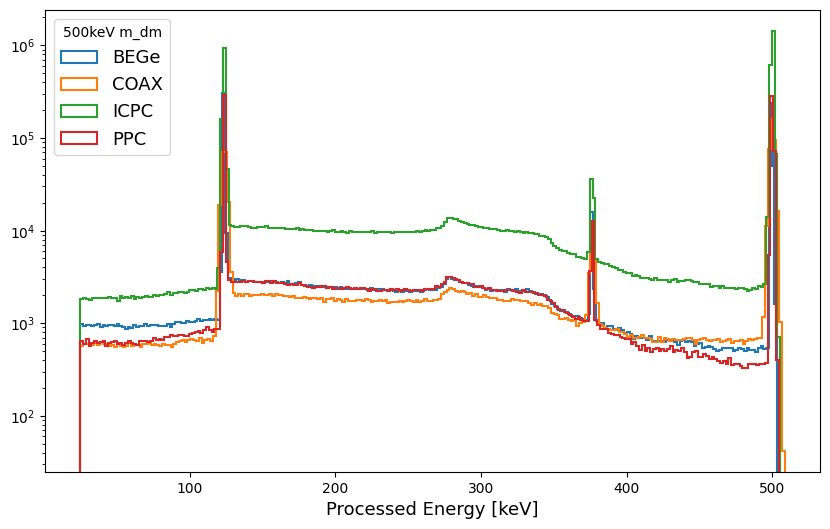

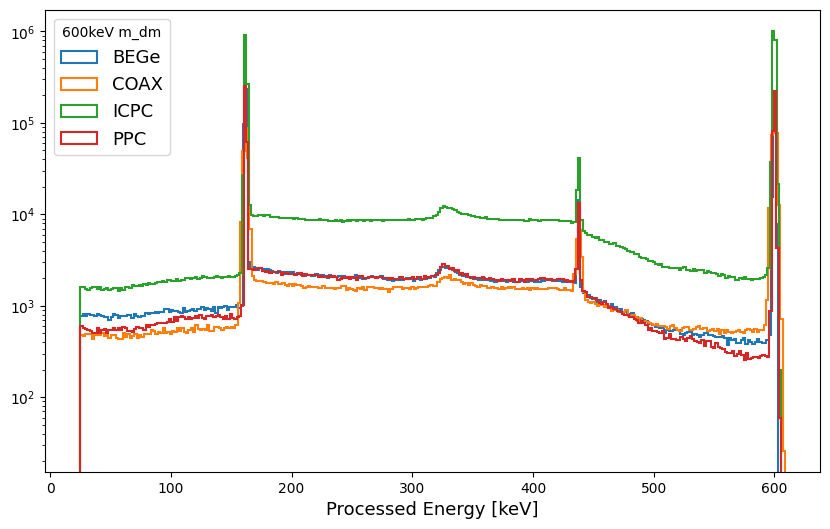

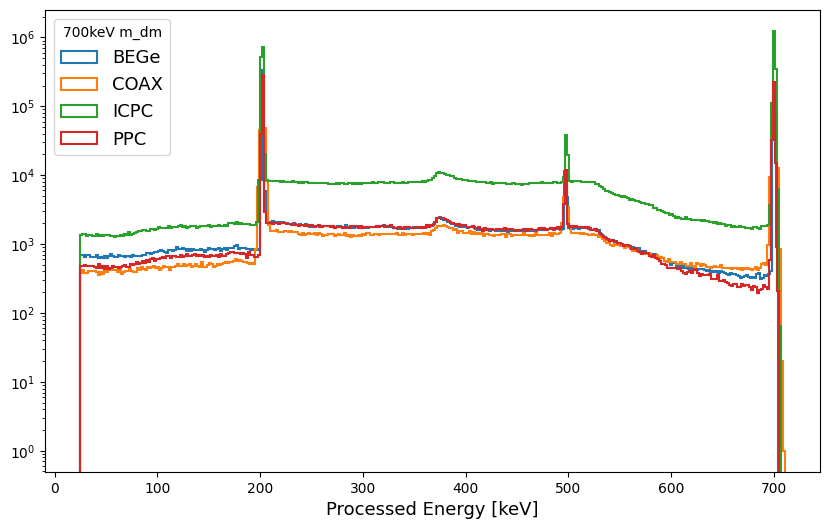

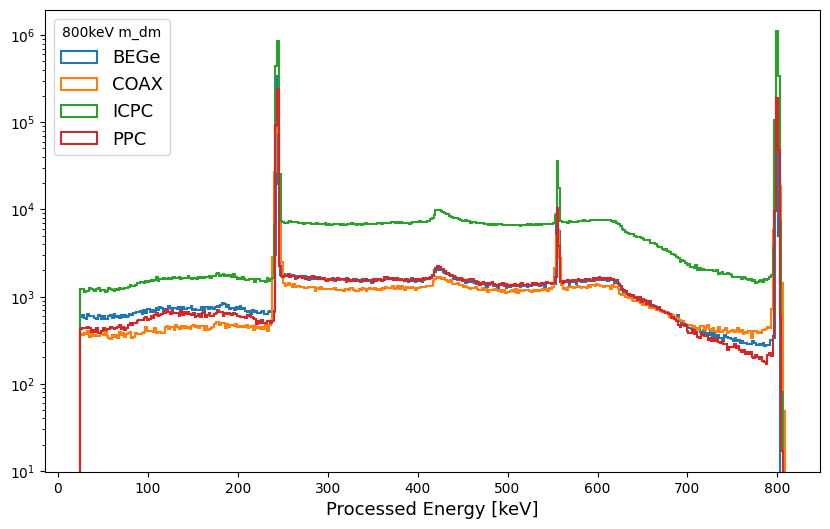

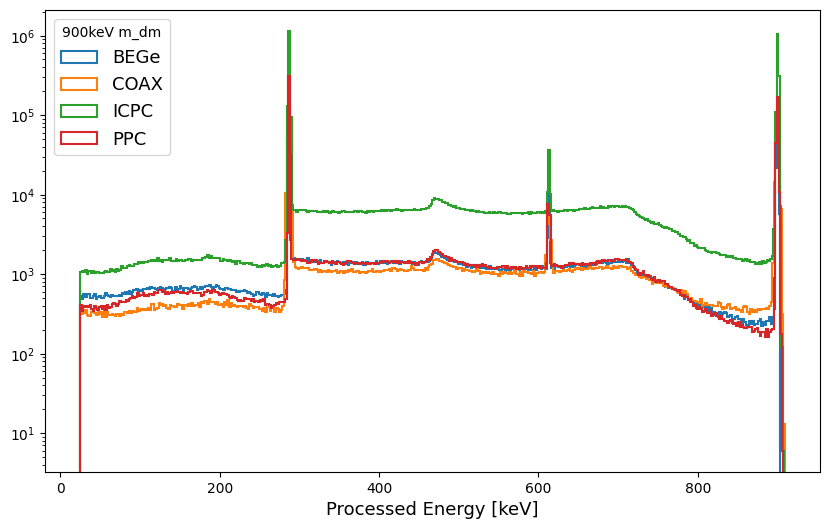

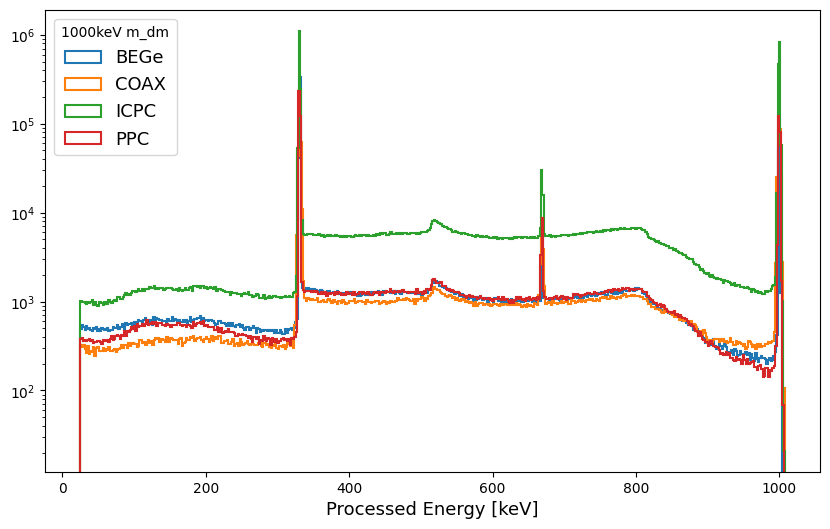

In [15]:
lw = 1.5
for ene in simulated_energies:
    
    plt.figure(figsize=(10, 6))
    
    for det_type in DET_TYPES:
        filtered_df = (
            lf.filter(
                (pl.col("sim_e") == ene) &
                pl.col("rawid").is_in(rawid_by_det_type[det_type])
            )
            .select([
                "energy"
            ])
            .collect()
        )
        
        plt.hist(filtered_df['energy'], bins=int(ene/2), label=det_type, histtype="step", linewidth=lw)

    plt.yscale("log")
    plt.legend(title=f"{ene}keV m_dm", fontsize=13)
    plt.xlabel("Processed Energy [keV]", fontsize=13)
    # plt.savefig(f"./plots/dark-compton/det_type_energy_{ene}.png", dpi=300)
    plt.show()


In [ ]:
ratio_dict = {}
fwhm = 5
for ene in tqdm(simulated_energies):
    ratio_dict[ene] = {}
    high = ene + fwhm
    low = ene - fwhm
    
    for ge in ges:

        rawid = chmap[ge].daq.rawid
        
        # n_evts = len(full_df.query('energy<@high and energy>@low and rawid==@rawid'))
        df_filtered = pl_df.filter(
                    (pl.col("rawid") == rawid) &
                    (pl.col("is_good_channel")) &
                    (pl.col("sim_e") == ene)
                )
        df_fep = df_filtered.filter(
                pl.col("energy").is_between(low, high)
            )
        
        n_evts = len(df_fep)
        # n_primaries = prim_dict[ene][ge]
        n_primaries = len(df_filtered)
            
        ratio_dict[ene][ge] = {}
        ratio_dict[ene][ge]['n_events'] = n_evts
        ratio_dict[ene][ge]['n_primaries'] = n_primaries
        if n_primaries == 0:
            ratio_dict[ene][ge]['ratio'] = np.nan
        else: 
            ratio_dict[ene][ge]['ratio'] = n_evts/n_primaries